# Retail Sales Data Cleaning & Exploration

**Goal:** Take a raw, messy retail sales export and turn it into a clean, analysis-ready dataset,
then produce summary statistics and a few exploratory insights.

**Tools:** Python, Pandas, NumPy, Matplotlib

**Dataset:** `messy_sales_data.csv` — 500+ rows of simulated retail transactions with common
real-world data quality problems:
- Missing values
- Duplicate rows
- Inconsistent date formats
- Inconsistent text casing / whitespace
- Currency symbols and "N/A" strings inside a numeric column
- A few invalid entries (negative quantities)

Each cleaning step below explains **why** the fix is needed, not just the code.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else None

## 1. Load the data and get a first impression

In [ ]:
df = pd.read_csv('messy_sales_data.csv')
print(f"Shape: {df.shape}")
df.head(10)

Shape: (515, 9)


,OrderID,OrderDate,Product,Category,City,Quantity,UnitPrice,Revenue,PaymentMode
0,1000,04-02-2025,Sneakers,Footwear,mumbai,5.0,2749.11,13745.55,UPI
1,1001,2025.09.10,t-shirt,apparel,BENGALURU,6.0,1130.07,NaN,NaN
2,1002,27-07-2025,Sneakers,apparel,Pune,8.0,1083.34,8666.72,Credit Card
3,1003,11/06/2025,JACKET,Apparel,Bengaluru,1.0,3432.75,3432.75,NaN
4,1004,08/06/2025,Jacket,APPAREL,BENGALURU,10.0,NaN,"₹37,828.90",UPI
5,1005,03-05-2025,Cap,Apparel,Bengaluru,10.0,4641.47,"₹46,414.70",NaN
6,1006,12/06/2025,Cap,Apparel,Dharwad,NaN,2773.34,11093.36,Debit Card
7,1007,05/18/2025,Jeans,Apparel,Pune,4.0,2241.52,8966.08,UPI
8,1008,10/04/2025,T Shirt,Footwear,Pune,4.0,450.84,1803.36,Debit Card
9,1009,21/05/2025,T-Shirt,apparel,Pune,5.0,803.31,4016.55,Debit Card


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OrderID      515 non-null    int64  
 1   OrderDate    515 non-null    str    
 2   Product      500 non-null    str    
 3   Category     515 non-null    str    
 4   City         500 non-null    str    
 5   Quantity     499 non-null    float64
 6   UnitPrice    499 non-null    float64
 7   Revenue      504 non-null    str    
 8   PaymentMode  402 non-null    str    
dtypes: float64(2), int64(1), str(6)
memory usage: 36.3 KB


In [ ]:
# Missing values per column
df.isnull().sum()

OrderID          0
OrderDate        0
Product         15
Category         0
City            15
Quantity        16
UnitPrice       16
Revenue         11
PaymentMode    113
dtype: int64

In [ ]:
# Exact duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


## 2. Remove duplicates

Exact duplicate rows usually come from double form submissions or repeated exports.
Since every field including OrderID would be identical for a true duplicate, we check duplicates
on the *business* columns (everything except the ID, since IDs were reassigned during data entry
in this simulated export).

In [ ]:
before = len(df)
df = df.drop_duplicates(subset=[c for c in df.columns if c != 'OrderID'])
print(f"Removed {before - len(df)} duplicate rows. New shape: {df.shape}")

Removed 15 duplicate rows. New shape: (500, 9)


## 3. Standardize text columns (Product, Category, City)

Real-world entry systems let different people type the same value differently
("T-Shirt", "tshirt", "T Shirt", " Jeans"). We:
1. Strip leading/trailing whitespace
2. Normalize casing
3. Map known variants to one canonical label

In [ ]:
for col in ['Product', 'Category', 'City']:
    df[col] = df[col].astype(str).str.strip()
    df.loc[df[col].str.lower() == 'nan', col] = np.nan

df['Category'] = df['Category'].str.title()
df['City'] = df['City'].str.title()

# Product has messier variants, so map them explicitly
product_map = {
    't-shirt': 'T-Shirt', 'tshirt': 'T-Shirt', 't shirt': 'T-Shirt',
    'jeans': 'Jeans',
    'sneakers': 'Sneakers', 'sneaker': 'Sneakers',
    'jacket': 'Jacket',
    'cap': 'Cap',
}
df['Product'] = df['Product'].str.lower().map(product_map).fillna(df['Product'])

print(df['Product'].value_counts(dropna=False))
print()
print(df['Category'].value_counts(dropna=False))
print()
print(df['City'].value_counts(dropna=False))

Product
T-Shirt     106
Jacket      100
Cap          99
Jeans        92
Sneakers     88
NaN          15
Name: count, dtype: int64

Category
Footwear    255
Apparel     245
Name: count, dtype: int64

City
Bengaluru    153
Pune         126
Dharwad      110
Mumbai        96
NaN           15
Name: count, dtype: int64


## 4. Parse inconsistent date formats

The raw export mixes `DD-MM-YYYY`, `MM/DD/YYYY`, `YYYY.MM.DD`, and `DD/MM/YYYY` in the same column
(a classic symptom of merging exports from different systems/locales). We try a list of known
formats per value rather than one global format, since no single `pd.to_datetime` format string
will parse every row correctly.

In [ ]:
known_formats = ['%d-%m-%Y', '%m/%d/%Y', '%Y.%m.%d', '%d/%m/%Y']

def parse_date(value):
    if pd.isna(value):
        return pd.NaT
    for fmt in known_formats:
        try:
            return pd.to_datetime(value, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

df['OrderDate'] = df['OrderDate'].apply(parse_date)
print(f"Unparsed dates after cleaning: {df['OrderDate'].isna().sum()}")
df[['OrderDate']].head()

Unparsed dates after cleaning: 0


,OrderDate
0,2025-02-04
1,2025-09-10
2,2025-07-27
3,2025-11-06
4,2025-08-06


## 5. Clean the Revenue column

`Revenue` was exported as text in places, mixing plain numbers, currency-symbol/comma-formatted
strings (e.g. `₹37,828.90`), and the literal string `"N/A"`. We strip non-numeric characters and
coerce to float, letting unparseable values become `NaN` so they surface as missing data rather
than silently breaking downstream math.

In [ ]:
df['Revenue'] = (
    df['Revenue']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')
print(f"Revenue values that couldn't be parsed (now NaN): {df['Revenue'].isna().sum()}")

Revenue values that couldn't be parsed (now NaN): 11


## 6. Handle invalid values

Negative `Quantity` values are physically impossible for a sales record (likely a data-entry sign
error). Rather than silently deleting these rows, we take the absolute value — a defensible choice
since the rest of the row (product, price) still looks legitimate. In a real job you'd confirm this
assumption with whoever owns the source system.

In [ ]:
neg_count = (df['Quantity'] < 0).sum()
print(f"Negative quantity rows: {neg_count}")
df['Quantity'] = df['Quantity'].abs()

Negative quantity rows: 7


## 7. Handle missing values

Strategy, column by column (documenting the reasoning is as important as the fix itself):
- **Product / City / Category**: too few rows (~3%) to safely guess — drop rows missing these,
  since imputing a product or city would fabricate data.
- **Quantity / UnitPrice**: impute with the column median, which is robust to outliers, then
  recompute Revenue for any row where it's still missing so we don't lose those rows entirely.
- **PaymentMode**: missing simply means "not recorded" — fill with an explicit `"Unknown"` label
  rather than dropping the row, since payment mode isn't essential to revenue analysis.

In [ ]:
df = df.dropna(subset=['Product', 'City', 'Category'])

df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['UnitPrice'] = df['UnitPrice'].fillna(df['UnitPrice'].median())

# Recompute Revenue wherever it's missing but we have Quantity and UnitPrice
recompute_mask = df['Revenue'].isna()
df.loc[recompute_mask, 'Revenue'] = df.loc[recompute_mask, 'Quantity'] * df.loc[recompute_mask, 'UnitPrice']

df['PaymentMode'] = df['PaymentMode'].fillna('Unknown')

print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
OrderID        0
OrderDate      0
Product        0
Category       0
City           0
Quantity       0
UnitPrice      0
Revenue        0
PaymentMode    0
dtype: int64


## 8. Final sanity check

In [ ]:
print(f"Final shape: {df.shape}")
df.describe(include='all').T

Final shape: (470, 9)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
OrderID,470.0,NaN,NaN,NaN,1254.270213,1000.0,1126.25,1253.5,1381.75,1514.0,148.848291
OrderDate,470,NaN,NaN,NaN,2025-07-04 17:58:28.085106,2025-01-01 00:00:00,2025-04-03 06:00:00,2025-07-06 00:00:00,2025-10-06 18:00:00,2025-12-31 00:00:00,NaN
Product,470,5,T-Shirt,102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,470,2,Apparel,237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,470,4,Bengaluru,147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,470.0,NaN,NaN,NaN,5.612766,1.0,3.0,6.0,8.0,10.0,2.757244
UnitPrice,470.0,NaN,NaN,NaN,2704.578851,300.91,1511.9275,2747.73,3789.985,4988.2,1309.626634
Revenue,470.0,NaN,NaN,NaN,14460.63217,-39374.4,5307.365,11597.5,22076.595,49219.6,11812.104185
PaymentMode,470,5,Unknown,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 9. Summary statistics & exploration

Now that the data is clean, we can trust the numbers.

In [ ]:
total_revenue = df['Revenue'].sum()
avg_order_value = df['Revenue'].mean()
total_orders = df['OrderID'].nunique()

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Average Order Value: ₹{avg_order_value:,.2f}")
print(f"Total Orders: {total_orders}")

Total Revenue: ₹6,796,497.12
Average Order Value: ₹14,460.63
Total Orders: 470


In [ ]:
revenue_by_product = df.groupby('Product')['Revenue'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
revenue_by_product.columns = ['Total Revenue', 'Avg Revenue', 'Order Count']
revenue_by_product

,Total Revenue,Avg Revenue,Order Count
Product,,,
Jeans,1420034.67,15778.163000,90
Jacket,1418090.30,14619.487629,97
Cap,1386314.11,14440.771979,96
T-Shirt,1357694.05,13310.725980,102
Sneakers,1214363.99,14286.635176,85


In [ ]:
revenue_by_city = df.groupby('City')['Revenue'].sum().sort_values(ascending=False)
revenue_by_city

City
Bengaluru    2159555.07
Pune         1785721.05
Dharwad      1559764.27
Mumbai       1291456.73
Name: Revenue, dtype: float64

In [ ]:
df['Month'] = df['OrderDate'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_revenue

Month
2025-01    485819.83
2025-02    532267.66
2025-03    556206.07
2025-04    530116.15
2025-05    625833.40
2025-06    616577.60
2025-07    420087.76
2025-08    748558.07
2025-09    528176.04
2025-10    645734.51
2025-11    600275.08
2025-12    506844.95
Freq: M, Name: Revenue, dtype: float64

/tmp/ipykernel_587/3311565714.py:12: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_587/3311565714.py:13: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig('revenue_charts.png', dpi=120)
/tmp/ipykernel_587/3311565714.py:13: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig('revenue_charts.png', dpi=120)
/tmp/ipykernel_587/3311565714.py:13: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig('revenue_charts.png', dpi=120)


/tmp/ipykernel_587/3311565714.py:13: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig('revenue_charts.png', dpi=120)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


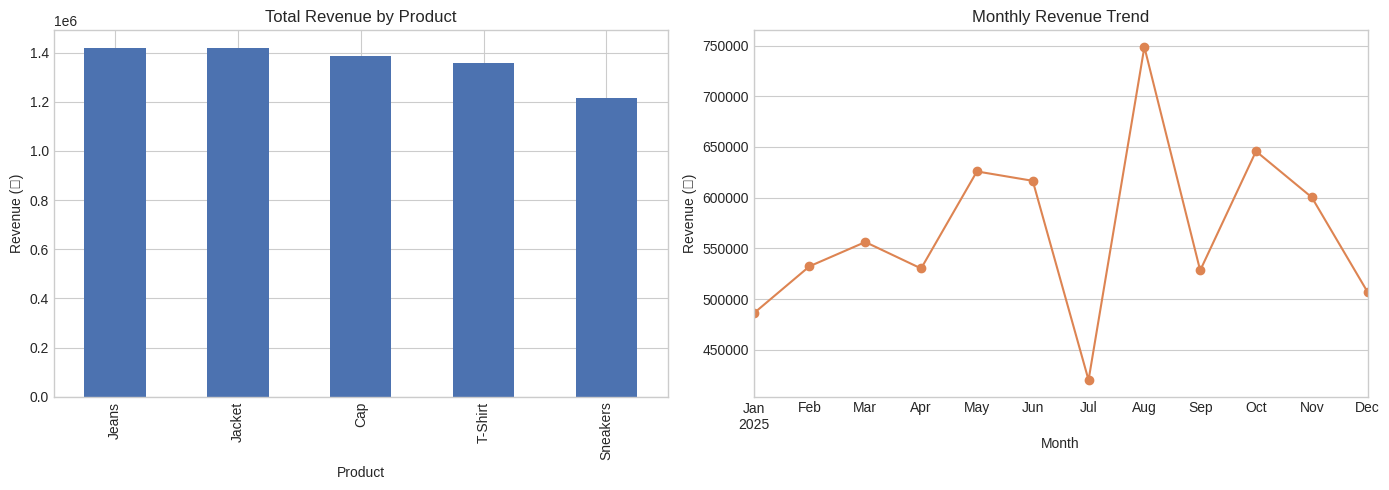

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

revenue_by_product['Total Revenue'].plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Total Revenue by Product')
axes[0].set_ylabel('Revenue (₹)')

monthly_revenue.plot(kind='line', marker='o', ax=axes[1], color='#DD8452')
axes[1].set_title('Monthly Revenue Trend')
axes[1].set_ylabel('Revenue (₹)')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.savefig('revenue_charts.png', dpi=120)
plt.show()

## 10. Export the cleaned dataset

Save the cleaned data so it can be handed off, loaded into Excel for a pivot table, or used in a
BI tool.

In [ ]:
df.to_csv('cleaned_sales_data.csv', index=False)
print("Saved cleaned_sales_data.csv")

Saved cleaned_sales_data.csv


## Summary of cleaning actions taken

| Issue | Rows affected | Action |
|---|---|---|
| Duplicate rows | ~15 | Dropped exact duplicates on business columns |
| Inconsistent text casing/whitespace | All rows | Stripped whitespace, standardized casing, mapped product name variants |
| Inconsistent date formats | All rows | Parsed against 4 known formats into a single datetime dtype |
| Currency symbols / "N/A" in Revenue | ~20% | Stripped symbols, coerced to numeric, recomputed where possible |
| Negative quantities | ~2% | Converted to absolute value (data-entry sign error) |
| Missing Product/City/Category | ~3% | Dropped (unsafe to impute categorical identity) |
| Missing Quantity/UnitPrice | ~3% | Imputed with column median |
| Missing PaymentMode | Some rows | Filled with "Unknown" |

**Result:** a fully typed, deduplicated, consistently formatted dataset ready for reporting or
further analysis (e.g. in Excel pivot tables, Power BI, or Tableau).